# Homework III

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import glob
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

import torch.nn.functional as F

plt.rcParams["image.interpolation"] = "bilinear"
plt.rcParams["image.cmap"] = "gray"

### SETUP PATH ###
WORK_DIR = Path('/content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-III') # Current workdir
MAYO_DATASET_PATH = Path('/content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Mayo')

### PARAMETERS ###
NOISE_LEVEL = 0.01
EPOCHS = 3 # Epochs' number

import sys
from pathlib import Path

here = WORK_DIR
for base in (here, *here.parents):
    if (base / 'IPPy').exists():
        sys.path.append(str(base))
        break
else:
    raise FileNotFoundError("Impossibile trovare la cartella IPPy.")

# 3. Ora le importazioni sono pulite, esplicite e a prova di bomba!
from IPPy import operators, utilities
from IPPy.utilities import gaussian_noise, get_device
from IPPy.nn.diffusion import DiffusionUNet, cosine_beta_schedule, extract, denormalize_to_01

weights_dir = WORK_DIR / 'weights'
weights_dir.mkdir(exist_ok=True)

device = get_device()
torch.manual_seed(0)

print('Working device:', device)
print('Weights directory:', weights_dir)

Working device: cuda
Weights directory: /content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-III/weights


## Controllo pesi

In [10]:
# ============================================================
# Check pretrained lecture weights
# ============================================================

vae_path = weights_dir / "VAE.pth"
ddpm_weights_path = weights_dir / "DDPMDenoiser.pth"

if not vae_path.exists():
    raise FileNotFoundError(
        f"Missing pretrained VAE weights: {vae_path}\n"
        "Copy VAE.pth from the lecture weights directory."
    )

if not ddpm_weights_path.exists():
    raise FileNotFoundError(
        f"Missing pretrained DDPM weights: {ddpm_weights_path}\n"
        "Copy DDPMDenoiser.pth from the lecture weights directory."
    )

print("Using pretrained lecture weights:")
print(" -", vae_path)
print(" -", ddpm_weights_path)

Using pretrained lecture weights:
 - /content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-III/weights/VAE.pth
 - /content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-III/weights/DDPMDenoiser.pth


## Data Pipeline, Corruption Model, and Pretrained Models

Device: cuda
Training images: 3306
Test images: 327
Weights directory: /content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-III/weights


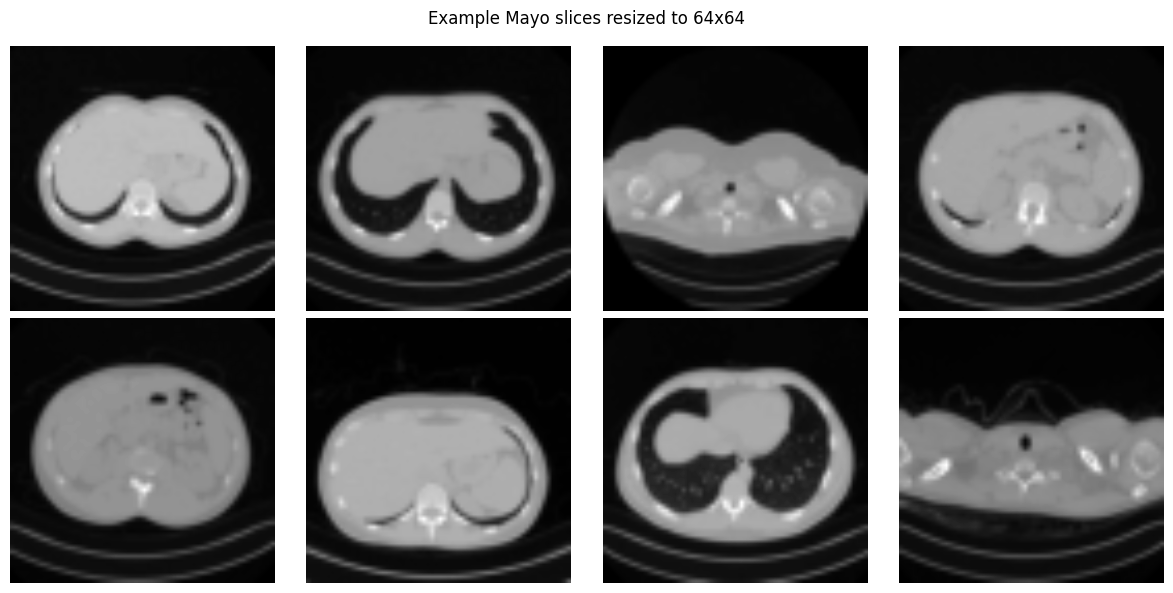

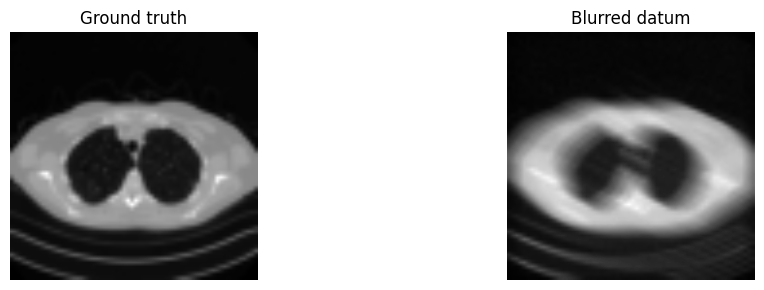

X_true = torch.Size([1, 1, 64, 64])
Y_delta = torch.Size([1, 1, 64, 64])


In [11]:
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)


def show_batch(batch, title, ncols=4):
    batch = batch.detach().cpu()
    n = min(len(batch), 8)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
    axes = axes.reshape(-1) if hasattr(axes, 'reshape') else [axes]
    for ax, image in zip(axes, batch[:n]):
        ax.imshow(image.squeeze(), cmap='gray')
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


device = utilities.get_device()
train_dataset = MayoDataset(data_path=str(MAYO_DATASET_PATH / 'train'), data_shape=64)
test_dataset = MayoDataset(data_path=str(MAYO_DATASET_PATH / 'test'), data_shape=64)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print('Device:', device)
print('Training images:', len(train_dataset))
print('Test images:', len(test_dataset))
print('Weights directory:', weights_dir)

x_batch = next(iter(train_loader))
show_batch(x_batch[:8], 'Example Mayo slices resized to 64x64')


K = operators.Blurring(
    img_shape=(64, 64),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=0.01)


def latent_reconstruction(generator, latent_shape, y_delta, K, num_steps=300, lr=1e-2, lam=1e-3):
    z = torch.randn(latent_shape, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([z], lr=lr)

    for _ in range(num_steps):
        x_hat = generator(z)
        data_loss = torch.mean((K(x_hat) - y_delta) ** 2)
        prior_loss = lam * torch.mean(z ** 2)
        loss = data_loss + prior_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        return generator(z).detach().clamp(0.0, 1.0)

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Blurred datum')
plt.axis('off')

plt.tight_layout()
plt.show()

print("X_true = " + str(x_true.shape))
print("Y_delta = " + str(y_delta.shape))

### VAE

/content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-III/weights/VAE.pth


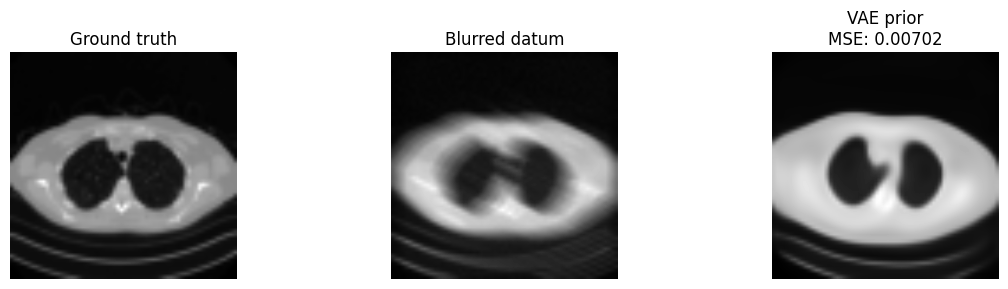

In [12]:
def norm_layer(channels):
    num_groups = 8 if channels >= 8 else 1
    return nn.GroupNorm(num_groups=num_groups, num_channels=channels)


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            norm_layer(channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            norm_layer(channels),
            nn.SiLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            norm_layer(out_ch),
            nn.SiLU(),
            ResidualBlock(out_ch),
        )

    def forward(self, x):
        return self.block(x)


class UpsampleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            norm_layer(out_ch),
            nn.SiLU(),
            ResidualBlock(out_ch),
        )

    def forward(self, x):
        return self.block(x)


class ConvVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim

        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            norm_layer(32),
            nn.SiLU(),
            ResidualBlock(32),
        )
        self.down1 = DownBlock(32, 64)
        self.down2 = DownBlock(64, 128)
        self.down3 = DownBlock(128, 256)
        self.down4 = DownBlock(256, 512)

        self.fc_mu = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 512 * 4 * 4)

        self.up1 = UpsampleBlock(512, 256)
        self.up2 = UpsampleBlock(256, 128)
        self.up3 = UpsampleBlock(128, 64)
        self.up4 = UpsampleBlock(64, 32)
        self.out_conv = nn.Sequential(
            norm_layer(32),
            nn.SiLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.stem(x)
        h = self.down1(h)
        h = self.down2(h)
        h = self.down3(h)
        h = self.down4(h)
        h = h.flatten(start_dim=1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h).clamp(min=-4.5, max=1.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z).view(z.shape[0], 512, 4, 4)
        h = self.up1(h)
        h = self.up2(h)
        h = self.up3(h)
        h = self.up4(h)
        return self.out_conv(h)

    def reconstruct_deterministic(self, x):
        mu, _ = self.encode(x)
        return self.decode(mu)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

#################################################################################
latent_dim = 64
vae_path = weights_dir / 'VAE.pth'
print(vae_path)


reloaded_vae = ConvVAE(latent_dim=latent_dim)
reloaded_vae.load_state_dict(torch.load(vae_path, map_location='cpu', weights_only=True))
reloaded_vae = reloaded_vae.to(device)
reloaded_vae.eval()

K = operators.Blurring(
    img_shape=(64, 64),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=0.01)


def latent_reconstruction(generator, latent_shape, y_delta, K, num_steps=300, lr=1e-2, lam=1e-3):
    z = torch.randn(latent_shape, device=device, requires_grad=True)
    optimizer = torch.optim.Adam([z], lr=lr)

    for _ in range(num_steps):
        x_hat = generator(z)
        data_loss = torch.mean((K(x_hat) - y_delta) ** 2)
        prior_loss = lam * torch.mean(z ** 2)
        loss = data_loss + prior_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        return generator(z).detach().clamp(0.0, 1.0)


vae_generator = lambda z: reloaded_vae.decode(z)

x_vae = latent_reconstruction(vae_generator, (1, 64), y_delta, K, num_steps=300, lr=1e-2, lam=1e-3)

mse_vae = torch.mean((x_vae - x_true) ** 2).item()

plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.imshow(x_true.cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(y_delta.cpu().squeeze(), cmap='gray')
plt.title('Blurred datum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(x_vae.cpu().squeeze(), cmap='gray')
plt.title(f'VAE prior\nMSE: {mse_vae:.5f}')
plt.axis('off')

plt.tight_layout()
plt.show()

### Diffusion Models

Device: cuda
Loaded diffusion weights from: /content/drive/MyDrive/Colab Notebooks/Esame CI/Homework/Code-III/weights/DDPMDenoiser.pth
Diffusion steps: 400


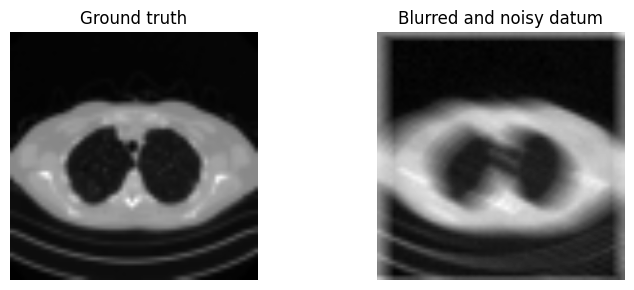

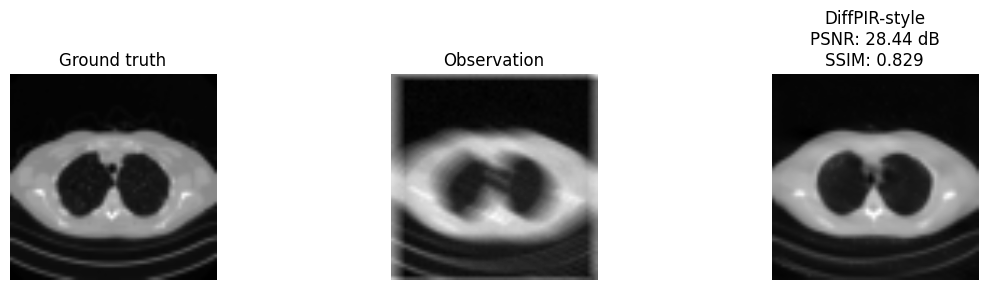

   Observation | MSE: 0.006232 | PSNR: 22.054 dB | SSIM: 0.6293
 DiffPIR-style | MSE: 0.001434 | PSNR: 28.436 dB | SSIM: 0.8288


In [13]:
weights_path = weights_dir / 'DDPMDenoiser.pth'

## From [0, 1] -> [-1, 1]
class MayoDataset(Dataset):
    def __init__(self, data_path, data_shape=64):
        super().__init__()
        self.fname_list = sorted(glob.glob(f'{data_path}/*/*.png'))
        self.transform = transforms.Compose([
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ])

    def __len__(self):
        return len(self.fname_list)

    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx]).convert('L')
        return self.transform(x)


def make_beta_schedule(num_steps):
    return cosine_beta_schedule(num_steps)


def predict_x0_from_eps(x_t, eps_pred, t, alpha_bars):
    return (x_t - extract((1 - alpha_bars).sqrt(), t, x_t.shape) * eps_pred) / extract(alpha_bars.sqrt(), t, x_t.shape)


def deterministic_ddim_update(x_t, x0_hat, eps_pred, t_next, alpha_bars):
    if t_next < 0:
        return x0_hat
    alpha_bar_next = alpha_bars[t_next].to(x_t.device)
    return torch.sqrt(alpha_bar_next) * x0_hat + torch.sqrt(1 - alpha_bar_next) * eps_pred


device = utilities.get_device()
num_diffusion_steps = 400
betas = make_beta_schedule(num_diffusion_steps)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

test_dataset = MayoDataset(data_path=str(MAYO_DATASET_PATH  / 'test'), data_shape=64)
if not weights_path.exists():
    raise FileNotFoundError(f'Diffusion weights not found at {weights_path}. Train the previous notebook first.')

model = DiffusionUNet(
    in_ch=1,
    base_ch=64,
    channel_mults=(1, 2, 4),
    time_dim=256,
    dropout=0.05,
    attn_levels=(1, 2),
)
model.load_state_dict(torch.load(weights_path, map_location='cpu'))
model = model.to(device)
model.eval()

K = operators.Blurring(
    img_shape=(64, 64),
    kernel_type='motion',
    kernel_size=9,
    motion_angle=20,
)

print('Device:', device)
print('Loaded diffusion weights from:', weights_path)
print('Diffusion steps:', num_diffusion_steps)

with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)
    y_delta = K(x_true)
    y_delta = y_delta + utilities.gaussian_noise(y_delta, noise_level=0.01)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(denormalize_to_01(x_true).cpu().squeeze(), cmap='gray')
plt.title('Ground truth')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(denormalize_to_01(y_delta).cpu().squeeze(), cmap='gray')
plt.title('Blurred and noisy datum')
plt.axis('off')

plt.tight_layout()
plt.show()

################################################################
def diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.6):
    schedule = torch.linspace(num_diffusion_steps - 1, 0, sample_steps, dtype=torch.long, device=device)
    x = y_delta.clone()

    for i in range(len(schedule) - 1):
        t_current = int(schedule[i].item())
        t_next = int(schedule[i + 1].item())
        t = torch.full((x.shape[0],), t_current, device=device, dtype=torch.long)

        with torch.no_grad():
            eps_pred = model(x, t)
            x0_hat = predict_x0_from_eps(x, eps_pred, t, alpha_bars).clamp(-1.0, 1.0)
            x_prior = deterministic_ddim_update(x, x0_hat, eps_pred, t_next, alpha_bars)
            residual = K(x_prior) - y_delta
            x = (x_prior - tau * K.T(residual)).clamp(-1.0, 1.0)

    return x.clamp(-1.0, 1.0).detach()


x_diffpir = diffpir_reconstruct(model, y_delta, K, alpha_bars, sample_steps=40, tau=0.6)

##################################################################

def mse(x, y):
    x_01 = denormalize_to_01(x.detach())
    y_01 = denormalize_to_01(y.detach())
    return torch.mean((x_01 - y_01) ** 2).item()


def psnr(x, y):
    mse_val = mse(x, y)
    return float('inf') if mse_val == 0 else -10 * math.log10(mse_val)


def ssim(x, y, window_size=11, sigma=1.5, c1=0.01 ** 2, c2=0.03 ** 2):
    x_01 = denormalize_to_01(x.detach())
    y_01 = denormalize_to_01(y.detach())
    coords = torch.arange(window_size, device=x_01.device, dtype=x_01.dtype) - window_size // 2
    gauss = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    gauss = gauss / gauss.sum()
    window_2d = torch.outer(gauss, gauss)
    window = window_2d.expand(x_01.shape[1], 1, window_size, window_size).contiguous()
    mu_x = torch.nn.functional.conv2d(x_01, window, padding=window_size // 2, groups=x_01.shape[1])
    mu_y = torch.nn.functional.conv2d(y_01, window, padding=window_size // 2, groups=y_01.shape[1])
    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y
    sigma_x2 = torch.nn.functional.conv2d(x_01 * x_01, window, padding=window_size // 2, groups=x_01.shape[1]) - mu_x2
    sigma_y2 = torch.nn.functional.conv2d(y_01 * y_01, window, padding=window_size // 2, groups=y_01.shape[1]) - mu_y2
    sigma_xy = torch.nn.functional.conv2d(x_01 * y_01, window, padding=window_size // 2, groups=x_01.shape[1]) - mu_xy
    ssim_map = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / ((mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2))
    return ssim_map.mean().item()


results = {
    'Observation': y_delta,
    'DiffPIR-style': x_diffpir,
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(denormalize_to_01(x_true.detach()).cpu().squeeze(), cmap='gray')
axes[0].set_title('Ground truth')
axes[0].axis('off')

for ax, (name, image) in zip(axes[1:], results.items()):
    ax.imshow(denormalize_to_01(image.detach()).cpu().squeeze(), cmap='gray')
    if name == 'Observation':
        ax.set_title(name)
    else:
        ax.set_title(f'{name}\nPSNR: {psnr(image, x_true):.2f} dB\nSSIM: {ssim(image, x_true):.3f}')
    ax.axis('off')

plt.tight_layout()
plt.show()

for name, image in results.items():
    print(f'{name:>14} | MSE: {mse(image, x_true):.6f} | PSNR: {psnr(image, x_true):.3f} dB | SSIM: {ssim(image, x_true):.4f}')

## Visual and Quantitative Comparison

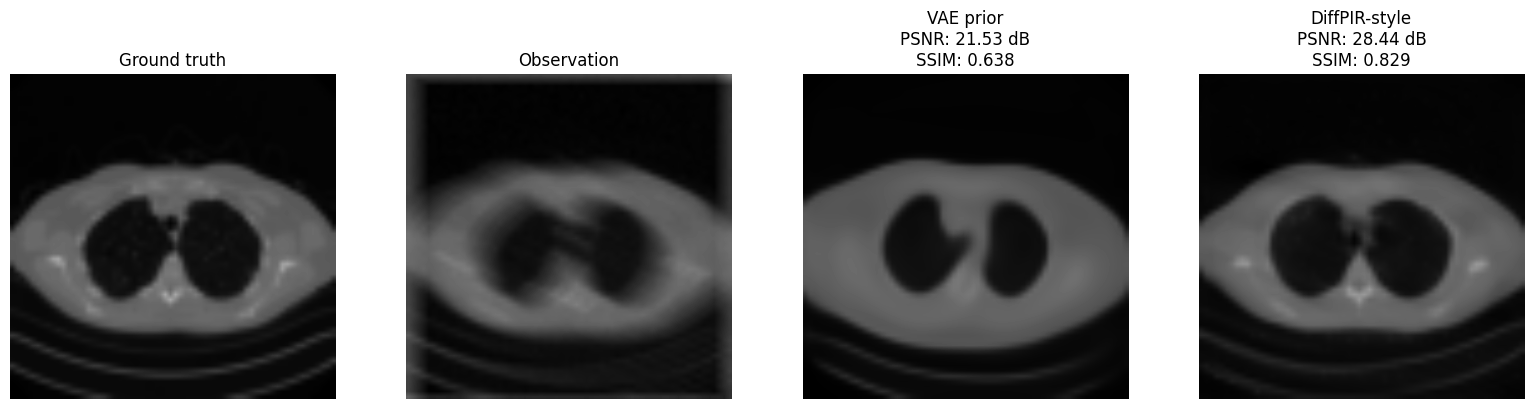

Final comparison on the same test image
     Observation | MSE: 0.006232 | PSNR: 22.054 dB | SSIM: 0.6293
       VAE prior | MSE: 0.007025 | PSNR: 21.534 dB | SSIM: 0.6382
   DiffPIR-style | MSE: 0.001434 | PSNR: 28.436 dB | SSIM: 0.8288


In [14]:
# ============================================================
# Final comparison: Observation vs VAE prior vs DiffPIR-style
# ============================================================

# Diffusion variables are in [-1, 1], so convert them to [0, 1]
x_true_01 = denormalize_to_01(x_true.detach()).clamp(0.0, 1.0)
y_delta_01 = denormalize_to_01(y_delta.detach()).clamp(0.0, 1.0)
x_diffpir_01 = denormalize_to_01(x_diffpir.detach()).clamp(0.0, 1.0)

# VAE output is already in [0, 1] because the VAE decoder ends with Sigmoid
x_vae_01 = x_vae.detach().clamp(0.0, 1.0)


def mse_01(x, y):
    return torch.mean((x - y) ** 2).item()


def psnr_01(x, y):
    mse_val = mse_01(x, y)
    return float("inf") if mse_val == 0 else -10 * math.log10(mse_val)


def ssim_01(x, y, window_size=11, sigma=1.5, c1=0.01 ** 2, c2=0.03 ** 2):
    coords = torch.arange(window_size, device=x.device, dtype=x.dtype) - window_size // 2
    gauss = torch.exp(-(coords ** 2) / (2 * sigma ** 2))
    gauss = gauss / gauss.sum()

    window_2d = torch.outer(gauss, gauss)
    window = window_2d.expand(x.shape[1], 1, window_size, window_size).contiguous()

    mu_x = torch.nn.functional.conv2d(
        x, window, padding=window_size // 2, groups=x.shape[1]
    )
    mu_y = torch.nn.functional.conv2d(
        y, window, padding=window_size // 2, groups=y.shape[1]
    )

    mu_x2 = mu_x ** 2
    mu_y2 = mu_y ** 2
    mu_xy = mu_x * mu_y

    sigma_x2 = torch.nn.functional.conv2d(
        x * x, window, padding=window_size // 2, groups=x.shape[1]
    ) - mu_x2

    sigma_y2 = torch.nn.functional.conv2d(
        y * y, window, padding=window_size // 2, groups=y.shape[1]
    ) - mu_y2

    sigma_xy = torch.nn.functional.conv2d(
        x * y, window, padding=window_size // 2, groups=x.shape[1]
    ) - mu_xy

    ssim_map = ((2 * mu_xy + c1) * (2 * sigma_xy + c2)) / (
        (mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2)
    )

    return ssim_map.mean().item()


comparison = {
    "Observation": y_delta_01,
    "VAE prior": x_vae_01,
    "DiffPIR-style": x_diffpir_01,
}

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.imshow(x_true_01.cpu().squeeze(), cmap="gray", vmin=0, vmax=1)
plt.title("Ground truth")
plt.axis("off")

for i, (name, image) in enumerate(comparison.items(), start=2):
    plt.subplot(1, 4, i)
    plt.imshow(image.cpu().squeeze(), cmap="gray", vmin=0, vmax=1)

    if name == "Observation":
        plt.title(name)
    else:
        plt.title(
            f"{name}\n"
            f"PSNR: {psnr_01(image, x_true_01):.2f} dB\n"
            f"SSIM: {ssim_01(image, x_true_01):.3f}"
        )

    plt.axis("off")

plt.tight_layout()
plt.show()


print("Final comparison on the same test image")
for name, image in comparison.items():
    print(
        f"{name:>16} | "
        f"MSE: {mse_01(image, x_true_01):.6f} | "
        f"PSNR: {psnr_01(image, x_true_01):.3f} dB | "
        f"SSIM: {ssim_01(image, x_true_01):.4f}"
    )

## Deliverables and Discussion

Il prior latente basato su VAE ha prodotto una ricostruzione liscia e visivamente plausibile, ma non è riuscito a recuperare i dettagli anatomici più fini. Nel mio esperimento, il VAE ha migliorato leggermente la SSIM rispetto all’osservazione corrotta, ma non ha migliorato MSE e PSNR. Questo suggerisce che il range del decoder fosse troppo restrittivo per questa specifica immagine di test. La regolarizzazione sul codice latente ha aiutato a mantenere la soluzione in una regione plausibile dello spazio latente, evitando immagini irrealistiche, ma ha anche limitato la capacità della ricostruzione di adattarsi perfettamente alla misura.

Il metodo basato su diffusion prior ha prodotto una ricostruzione nettamente migliore rispetto al VAE. La ricostruzione DiffPIR-style ha migliorato l’osservazione da PSNR 22.05 dB e SSIM 0.629 a PSNR 28.44 dB e SSIM 0.829. A differenza del VAE, il metodo diffusion non è vincolato esplicitamente al range di un decoder a bassa dimensionalità; per questo riesce a recuperare dettagli più realistici mantenendo allo stesso tempo coerenza con la misura. Tuttavia, i metodi diffusion sono più sensibili agli iperparametri, come il numero di step di campionamento e il passo della correzione di data consistency.

Il metodo DiffPIR-style è risultato sia più coerente con i dati sia più plausibile visivamente. Ha ottenuto i migliori valori di MSE, PSNR e SSIM tra i metodi testati, e visivamente ha recuperato in modo più fedele le principali strutture anatomiche. La ricostruzione VAE, invece, è più liscia e generica: appare plausibile come immagine medica, ma è meno fedele alla specifica slice di ground truth.

Sì, ho osservato segni di bias del modello. Il VAE mostra una tendenza evidente a produrre strutture troppo lisce e medie, perdendo dettagli specifici dell’immagine. Questo è un effetto del vincolo imposto dallo spazio latente e della capacità limitata del decoder. Il metodo diffusion produce un’immagine più accurata, ma può comunque introdurre dettagli plausibili ma non necessariamente presenti nella misura, specialmente nelle regioni in cui l’operatore di blur ha rimosso informazione. Per questo motivo la plausibilità visiva da sola non è sufficiente: una ricostruzione realistica non è automaticamente affidabile.

È importante confrontare i metodi sulla stessa immagine corrotta e con lo stesso operatore diretto perché i problemi inversi dipendono fortemente sia dall’operatore K sia dalla specifica realizzazione del rumore. Se i metodi fossero testati su immagini corrotte diverse, il confronto non sarebbe equo. Usare la stessa immagine pulita, lo stesso operatore K e lo stesso dato corrotto permette di attribuire le differenze osservate ai metodi di ricostruzione, e non a differenze negli input o nel rumore.

Non ho implementato l’estensione opzionale con GAN prior o un secondo metodo diffusion. Il confronto si è concentrato sulle parti obbligatorie: un prior latente basato su VAE e un prior diffusion in stile DiffPIR. Anche con questi due metodi, l’esperimento mostra chiaramente il compromesso principale tra un generatore latente più vincolato e un prior diffusion più flessibile.